In [2]:
import numpy as np 
import pandas as pd
import sys , os
import matplotlib.pyplot as plt 

sys.path.append(os.path.join(os.getcwd(),'..','src'))

from decision_trees import DecisionTree
from utils import *

In [3]:
np.random.seed(42)
n = 500
X = np.random.uniform(0, 10, size=(n, 1))
y = np.sin(X[:, 0]) + np.random.normal(0, 0.2, size=n)

idx = np.random.permutation(n)
X = X[idx]
y = y[idx]

split = int(0.8 * n)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print('Loaded synthetic regression data:')
print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_test :', X_test.shape, 'y_test :', y_test.shape) 

Loaded synthetic regression data:
X_train: (400, 1) y_train: (400,)
X_test : (100, 1) y_test : (100,)


In [4]:
model = DecisionTree(criterion='variance', max_depth=3, task='regression')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('\nTest metrics at depth 3:')
print('MSE:', mse(y_test, y_pred))
print('MAE:', mae(y_test, y_pred)) 


Test metrics at depth 3:
MSE: 0.12338108655068386
MAE: 0.2695388549400035


In [6]:
rows = []
for d in [1, 2, 3, 4, 5, 6, 8, 10]:
    m = DecisionTree(criterion='variance', max_depth=d, task='regression')
    m.fit(X_train, y_train)
    tr_pred = m.predict(X_train)
    te_pred = m.predict(X_test)
    rows.append({
        'depth': d,
        'train_mse': mse(y_train, tr_pred),
        'test_mse': mse(y_test, te_pred)
    })

df = pd.DataFrame(rows)
print('\nDepth study:')
print(df.to_markdown(index=False))

plt.figure(figsize=(7, 4))
plt.plot(df['depth'], df['train_mse'], marker='o', label='Train MSE')
plt.plot(df['depth'], df['test_mse'], marker='o', label='Test MSE')
plt.xlabel('Max depth')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.savefig('../results/reg_depth_mse.png', dpi=160)
plt.close() 


Depth study:
|   depth |   train_mse |   test_mse |
|--------:|------------:|-----------:|
|       1 |  0.390165   |  0.275122  |
|       2 |  0.168121   |  0.237879  |
|       3 |  0.0808136  |  0.123381  |
|       4 |  0.046795   |  0.0818168 |
|       5 |  0.03395    |  0.0565193 |
|       6 |  0.0270977  |  0.0572998 |
|       8 |  0.0160938  |  0.0680599 |
|      10 |  0.00792482 |  0.0705769 |


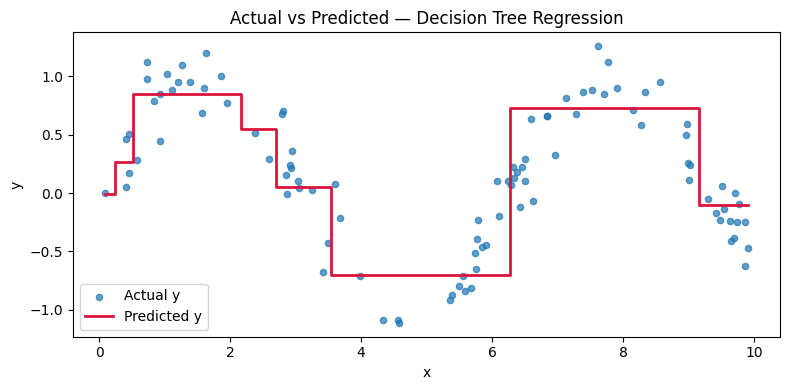

In [10]:
y_pred = model.predict(X_test)

order = np.argsort(X_test[:, 0])
X_sorted = X_test[order, 0]
y_test_sorted = y_test[order]
y_pred_sorted = y_pred[order]

plt.figure(figsize=(8, 4))
plt.scatter(X_test[:, 0], y_test, s=20, alpha=0.7, label='Actual y')
plt.step(X_sorted, y_pred_sorted, where='mid', color='crimson', linewidth=2, label='Predicted y')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Actual vs Predicted — Decision Tree Regression')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
print('\nTree structure:')
print_tree(model.root, feature_names=['x']) 


Tree structure:
If x < 2.7109064151798505:
  If x < 0.5399249842522252:
    If x < 0.21928215015814156:
      Leaf: value = -0.009296196298642041
    Else:
      Leaf: value = 0.26800493507957257
  Else:
    If x < 2.332178547420111:
      Leaf: value = 0.8531060851750545
    Else:
      Leaf: value = 0.5527251523767364
Else:
  If x < 6.243751957666182:
    If x < 3.5213362028906574:
      Leaf: value = 0.04912447686788138
    Else:
      Leaf: value = -0.7073301649264341
  Else:
    If x < 9.053663091876636:
      Leaf: value = 0.7318073776083152
    Else:
      Leaf: value = -0.10320756781990581


In [9]:
best_row = df.loc[df['test_mse'].idxmin()]
print('\nSummary:')
print(f"Best depth: {int(best_row['depth'])} with test MSE {best_row['test_mse']:.4f}")
print('Overfitting starts when train MSE keeps dropping but test MSE stops improving or rises.')
print('The step-function plot shows that decision trees approximate smooth functions with piecewise-constant intervals, so they cannot model a smooth sine curve continuously.')


Summary:
Best depth: 5 with test MSE 0.0565
Overfitting starts when train MSE keeps dropping but test MSE stops improving or rises.
The step-function plot shows that decision trees approximate smooth functions with piecewise-constant intervals, so they cannot model a smooth sine curve continuously.
